<a href="https://colab.research.google.com/github/JonHemrick/ECGR4106/blob/HW3/HW3_Problem3_ECGR4106.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving vast_english_french.txt to vast_english_french.txt


In [3]:
import re
import random
import math
import time
import unicodedata
from io import open

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import nltk
nltk.download('punkt', quiet=True)

torch.manual_seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
smoothie = SmoothingFunction().method4


Using device: cuda


In [4]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {}
        self.word2count = {}
        self.index2word = {0: "PAD", 1: "SOS", 2: "EOS"}
        self.n_words = 3

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1


def normalize_string(s, is_french=False):
    s = s.strip()
    if not is_french:
        s = ''.join(
            c for c in unicodedata.normalize('NFD', s.lower())
            if unicodedata.category(c) != 'Mn'
        )
    else:
        s = s.lower()
    s = re.sub(r"([.!?,])", r" \1", s)
    s = re.sub(r"[^a-zA-Z0-9àâäéèêëïîôöùûüç.!?,'\- ]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def read_data(path):
    lines = open(path, encoding='utf-8').read().strip().split('\n')
    pairs = []
    for line in lines:
        if not line.strip():
            continue
        parts = line.split('\t')
        if len(parts) < 2:
            continue
        eng, fra = parts[0], parts[1]
        pairs.append([normalize_string(fra, is_french=True),
                       normalize_string(eng, is_french=False)])
    return pairs


DATA_PATH = "vast_english_french.txt"
pairs = read_data(DATA_PATH)

MAX_LENGTH = 20
pairs = [p for p in pairs if len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH]
print(f"{len(pairs)} pairs after length filtering")

input_lang = Lang("fra")
output_lang = Lang("eng")

for fra, eng in pairs:
    input_lang.add_sentence(fra)
    output_lang.add_sentence(eng)

print(f"French (source) vocabulary size: {input_lang.n_words}")
print(f"English (target) vocabulary size: {output_lang.n_words}")

random.shuffle(pairs)
split_idx = int(0.8 * len(pairs))
train_pairs = pairs[:split_idx]
val_pairs = pairs[split_idx:]
print(f"Training pairs: {len(train_pairs)} | Validation pairs: {len(val_pairs)}")


555 pairs after length filtering
French (source) vocabulary size: 1138
English (target) vocabulary size: 1016
Training pairs: 444 | Validation pairs: 111


In [5]:
def tensor_from_sentence(lang, sentence):
    indexes = [lang.word2index[w] for w in sentence.split(' ') if w in lang.word2index]
    indexes.append(EOS_token)
    return torch.tensor(indexes, dtype=torch.long, device=device).view(-1, 1)


def tensors_from_pair(pair):
    input_tensor = tensor_from_sentence(input_lang, pair[0])
    target_tensor = tensor_from_sentence(output_lang, pair[1])
    return input_tensor, target_tensor


In [6]:
HIDDEN_SIZE = 256

class EncoderGRU(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input_tensor, hidden):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        output, hidden = self.gru(embedded, hidden)
        return output, hidden

    def init_hidden(self):
        return torch.zeros(1, 1, self.hidden_size, device=device)


class DecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.log_softmax = nn.LogSoftmax(dim=1)
        self.relu = nn.ReLU()

    def forward(self, input_tensor, hidden):
        output = self.embedding(input_tensor).view(1, 1, -1)
        output = self.relu(output)
        output, hidden = self.gru(output, hidden)
        output = self.log_softmax(self.out(output[0]))
        return output, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.Wa = nn.Linear(hidden_size, hidden_size)
        self.Ua = nn.Linear(hidden_size, hidden_size)
        self.Va = nn.Linear(hidden_size, 1)

    def forward(self, decoder_hidden, encoder_outputs):
        decoder_hidden_t = decoder_hidden.permute(1, 0, 2)
        scores = self.Va(torch.tanh(self.Wa(decoder_hidden_t) + self.Ua(encoder_outputs.permute(1, 0, 2))))
        scores = scores.squeeze(2)
        attn_weights = F.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs.permute(1, 0, 2))
        return context, attn_weights


class AttnDecoderGRU(nn.Module):
    def __init__(self, hidden_size, output_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.attention = BahdanauAttention(hidden_size)
        self.gru = nn.GRU(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.log_softmax = nn.LogSoftmax(dim=1)

    def forward(self, input_tensor, hidden, encoder_outputs):
        embedded = self.embedding(input_tensor).view(1, 1, -1)
        context, attn_weights = self.attention(hidden, encoder_outputs)
        gru_input = torch.cat((embedded, context.permute(1, 0, 2)), dim=2)
        output, hidden = self.gru(gru_input, hidden)
        output = self.log_softmax(self.out(output[0]))
        return output, hidden, attn_weights


In [7]:
TEACHER_FORCING_RATIO = 0.5

def train_step(input_tensor, target_tensor, encoder, decoder,
                encoder_optimizer, decoder_optimizer, criterion, use_attention):
    encoder_hidden = encoder.init_hidden()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs_list = []
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
        encoder_outputs_list.append(encoder_output)
    encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

    decoder_input = torch.tensor([[SOS_token]], device=device)
    decoder_hidden = encoder_hidden

    loss = 0
    use_teacher_forcing = random.random() < TEACHER_FORCING_RATIO

    for di in range(target_length):
        if use_attention:
            decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
        else:
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)

        loss += criterion(decoder_output, target_tensor[di])

        if use_teacher_forcing:
            decoder_input = target_tensor[di]
        else:
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            if decoder_input.item() == EOS_token:
                break

    loss.backward()
    encoder_optimizer.step()
    decoder_optimizer.step()
    return loss.item() / target_length


def evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion, use_attention):
    with torch.no_grad():
        encoder_hidden = encoder.init_hidden()
        input_length = input_tensor.size(0)
        target_length = target_tensor.size(0)

        encoder_outputs_list = []
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs_list.append(encoder_output)
        encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        loss = 0
        for di in range(target_length):
            if use_attention:
                decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            else:
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze().detach().view(1, 1)
            loss += criterion(decoder_output, target_tensor[di])
            if decoder_input.item() == EOS_token:
                break
        return loss.item() / target_length


def run_training(encoder, decoder, n_epochs, use_attention, learning_rate=0.01):
    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)
    criterion = nn.NLLLoss()

    train_tensors = [tensors_from_pair(p) for p in train_pairs]
    val_tensors = [tensors_from_pair(p) for p in val_pairs]

    train_losses, val_losses = [], []
    start = time.time()

    for epoch in range(1, n_epochs + 1):
        encoder.train(); decoder.train()
        random.shuffle(train_tensors)
        total_train_loss = 0
        for input_tensor, target_tensor in train_tensors:
            total_train_loss += train_step(input_tensor, target_tensor, encoder, decoder,
                                            encoder_optimizer, decoder_optimizer, criterion, use_attention)
        avg_train_loss = total_train_loss / len(train_tensors)

        encoder.eval(); decoder.eval()
        total_val_loss = 0
        for input_tensor, target_tensor in val_tensors:
            total_val_loss += evaluate_loss(input_tensor, target_tensor, encoder, decoder, criterion, use_attention)
        avg_val_loss = total_val_loss / len(val_tensors)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        elapsed = time.time() - start
        print(f"Epoch {epoch:3d}/{n_epochs} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Elapsed: {elapsed:.1f}s")

    return train_losses, val_losses


def evaluate_sentence(encoder, decoder, sentence, use_attention, max_length=MAX_LENGTH):
    with torch.no_grad():
        input_tensor = tensor_from_sentence(input_lang, sentence)
        input_length = input_tensor.size(0)
        encoder_hidden = encoder.init_hidden()

        encoder_outputs_list = []
        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(input_tensor[ei], encoder_hidden)
            encoder_outputs_list.append(encoder_output)
        encoder_outputs_cat = torch.cat(encoder_outputs_list, dim=0)

        decoder_input = torch.tensor([[SOS_token]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        for di in range(max_length):
            if use_attention:
                decoder_output, decoder_hidden, _ = decoder(decoder_input, decoder_hidden, encoder_outputs_cat)
            else:
                decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            topv, topi = decoder_output.topk(1)
            if topi.item() == EOS_token:
                break
            decoded_words.append(output_lang.index2word[topi.item()])
            decoder_input = topi.squeeze().detach().view(1, 1)
        return decoded_words


def evaluate_full_validation_set(encoder, decoder, val_pairs, use_attention):
    encoder.eval(); decoder.eval()
    exact_matches = 0
    bleu_scores = []
    results = []
    for src, tgt in val_pairs:
        predicted_words = evaluate_sentence(encoder, decoder, src, use_attention)
        predicted_sentence = ' '.join(predicted_words)
        reference_words = tgt.split(' ')

        is_exact_match = (predicted_words == reference_words)
        if is_exact_match:
            exact_matches += 1

        bleu = sentence_bleu([reference_words], predicted_words,
                              weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smoothie)
        bleu_scores.append(bleu)

        results.append({"source": src, "reference": tgt, "predicted": predicted_sentence,
                         "exact_match": is_exact_match, "bleu": bleu})

    exact_match_accuracy = exact_matches / len(val_pairs)
    avg_bleu = sum(bleu_scores) / len(bleu_scores)
    return exact_match_accuracy, avg_bleu, results


In [8]:
N_EPOCHS = 10
LEARNING_RATE = 0.01

baseline_encoder = EncoderGRU(input_lang.n_words, HIDDEN_SIZE).to(device)
baseline_decoder = DecoderGRU(HIDDEN_SIZE, output_lang.n_words).to(device)

baseline_train_losses, baseline_val_losses = run_training(
    baseline_encoder, baseline_decoder, N_EPOCHS, use_attention=False, learning_rate=LEARNING_RATE)


Epoch   1/10 | Train Loss: 4.3834 | Val Loss: 2.9729 | Elapsed: 6.9s
Epoch   2/10 | Train Loss: 4.1406 | Val Loss: 3.6967 | Elapsed: 13.4s
Epoch   3/10 | Train Loss: 4.0158 | Val Loss: 3.5128 | Elapsed: 19.8s
Epoch   4/10 | Train Loss: 3.8779 | Val Loss: 3.7440 | Elapsed: 26.2s
Epoch   5/10 | Train Loss: 3.5963 | Val Loss: 4.0337 | Elapsed: 32.7s
Epoch   6/10 | Train Loss: 3.3172 | Val Loss: 4.0685 | Elapsed: 39.2s
Epoch   7/10 | Train Loss: 3.0811 | Val Loss: 4.1217 | Elapsed: 45.8s
Epoch   8/10 | Train Loss: 2.9192 | Val Loss: 3.8927 | Elapsed: 52.5s
Epoch   9/10 | Train Loss: 2.6795 | Val Loss: 3.7810 | Elapsed: 59.2s
Epoch  10/10 | Train Loss: 2.4133 | Val Loss: 4.1960 | Elapsed: 66.0s


In [9]:
baseline_exact_match, baseline_bleu, baseline_val_results = evaluate_full_validation_set(
    baseline_encoder, baseline_decoder, val_pairs, use_attention=False)

print(f"[Baseline, Fr->En] Validation Exact Match Accuracy: {baseline_exact_match*100:.2f}%")
print(f"[Baseline, Fr->En] Validation BLEU-4: {baseline_bleu:.4f}")


[Baseline, Fr->En] Validation Exact Match Accuracy: 0.00%
[Baseline, Fr->En] Validation BLEU-4: 0.0685


In [10]:
attn_encoder = EncoderGRU(input_lang.n_words, HIDDEN_SIZE).to(device)
attn_decoder = AttnDecoderGRU(HIDDEN_SIZE, output_lang.n_words).to(device)

attn_train_losses, attn_val_losses = run_training(
    attn_encoder, attn_decoder, N_EPOCHS, use_attention=True, learning_rate=LEARNING_RATE)


Epoch   1/10 | Train Loss: 4.5351 | Val Loss: 3.1256 | Elapsed: 9.1s
Epoch   2/10 | Train Loss: 4.1463 | Val Loss: 3.8147 | Elapsed: 18.4s
Epoch   3/10 | Train Loss: 3.8231 | Val Loss: 3.5627 | Elapsed: 27.6s
Epoch   4/10 | Train Loss: 3.5114 | Val Loss: 3.8727 | Elapsed: 37.2s
Epoch   5/10 | Train Loss: 3.1406 | Val Loss: 3.5498 | Elapsed: 46.6s
Epoch   6/10 | Train Loss: 2.8780 | Val Loss: 3.3633 | Elapsed: 56.0s
Epoch   7/10 | Train Loss: 2.5839 | Val Loss: 3.8957 | Elapsed: 65.8s
Epoch   8/10 | Train Loss: 2.3078 | Val Loss: 3.6588 | Elapsed: 75.5s
Epoch   9/10 | Train Loss: 1.9960 | Val Loss: 3.6215 | Elapsed: 85.2s
Epoch  10/10 | Train Loss: 1.7486 | Val Loss: 3.8089 | Elapsed: 95.0s


In [11]:
attn_exact_match, attn_bleu, attn_val_results = evaluate_full_validation_set(
    attn_encoder, attn_decoder, val_pairs, use_attention=True)

print(f"[Attention, Fr->En] Validation Exact Match Accuracy: {attn_exact_match*100:.2f}%")
print(f"[Attention, Fr->En] Validation BLEU-4: {attn_bleu:.4f}")


[Attention, Fr->En] Validation Exact Match Accuracy: 0.00%
[Attention, Fr->En] Validation BLEU-4: 0.1345


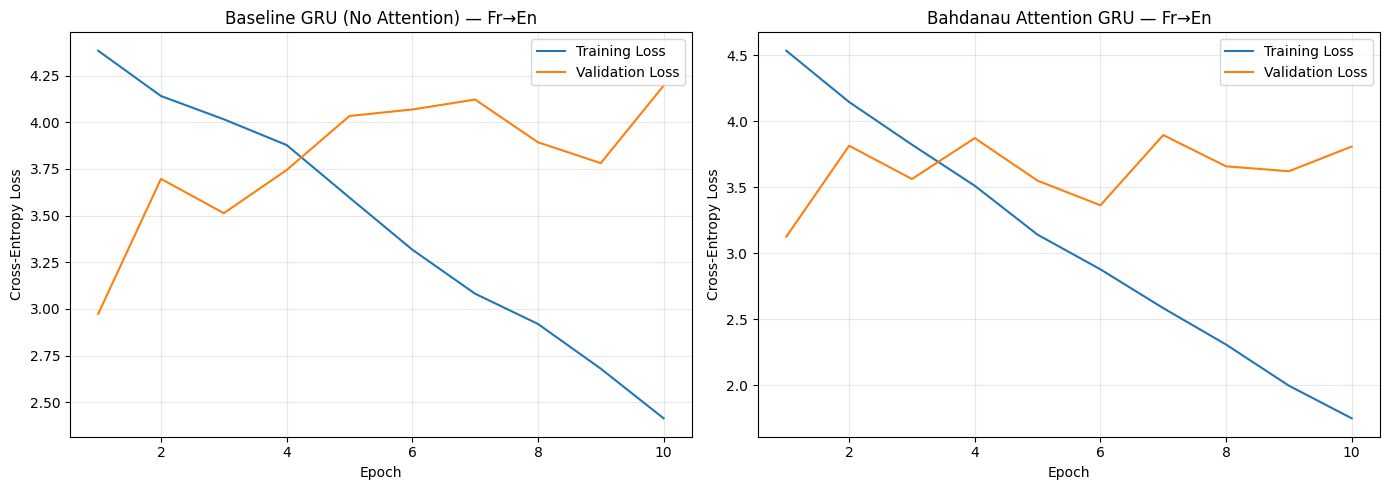

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, N_EPOCHS + 1), baseline_train_losses, label="Training Loss")
axes[0].plot(range(1, N_EPOCHS + 1), baseline_val_losses, label="Validation Loss")
axes[0].set_title("Baseline GRU (No Attention) — Fr→En")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, N_EPOCHS + 1), attn_train_losses, label="Training Loss")
axes[1].plot(range(1, N_EPOCHS + 1), attn_val_losses, label="Validation Loss")
axes[1].set_title("Bahdanau Attention GRU — Fr→En")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Cross-Entropy Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("problem3_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()


In [13]:
random.seed(7)
sample_indices = random.sample(range(len(val_pairs)), 5)


for idx in sample_indices:
    src, tgt = val_pairs[idx]
    b_result = baseline_val_results[idx]
    a_result = attn_val_results[idx]
    print(f"French (source):        {src}")
    print(f"Reference (English):    {tgt}")
    print(f"  Baseline prediction:  {b_result['predicted']:<50} | Exact: {b_result['exact_match']!s:<5} | BLEU: {b_result['bleu']:.4f}")
    print(f"  Attention prediction: {a_result['predicted']:<50} | Exact: {a_result['exact_match']!s:<5} | BLEU: {a_result['bleu']:.4f}")



French (source):        il parle couramment six langues internationales
Reference (English):    he speaks six international languages completely fluently
  Baseline prediction:  he drives a black                                  | Exact: False | BLEU: 0.0288
  Attention prediction: he speaks five languages fluently                  | Exact: False | BLEU: 0.0966
French (source):        il passe l'aspirateur dans toute sa maison tous les vendredis après-midi
Reference (English):    he vacuums his entire house every friday afternoon
  Baseline prediction:  i look forward to the the the tomorrow             | Exact: False | BLEU: 0.0000
  Attention prediction: he works as a software software company            | Exact: False | BLEU: 0.0281
French (source):        ils ont construit un grand mur de pierre autour de la propriété
Reference (English):    they constructed a large stone wall around the property
  Baseline prediction:  they built a large a                               | Exact: Fa

In [14]:
print(f"{'Direction':<14}{'Architecture':<16}{'Final Train Loss':<20}{'Final Val Loss':<18}{'Exact Match':<15}{'BLEU-4'}")
print(f"{'Fr->En':<14}{'Baseline':<16}{baseline_train_losses[-1]:<20.4f}{baseline_val_losses[-1]:<18.4f}{baseline_exact_match*100:<15.2f}{baseline_bleu:.4f}")
print(f"{'Fr->En':<14}{'Attention':<16}{attn_train_losses[-1]:<20.4f}{attn_val_losses[-1]:<18.4f}{attn_exact_match*100:<15.2f}{attn_bleu:.4f}")


Direction     Architecture    Final Train Loss    Final Val Loss    Exact Match    BLEU-4
Fr->En        Baseline        2.4133              4.1960            0.00           0.0685
Fr->En        Attention       1.7486              3.8089            0.00           0.1345
